# Modelo Tradicional (Sin TDA) - Clasificación de Circuitos Críticos

Proyecto: Aseguramiento del Abastecimiento a Líneas Críticas (Ternium).

Clasificamos circuitos logísticos como críticos o no críticos usando solo variables operativas, sin descriptores topológicos. El target es `score_prioridad` binarizado al percentil 75. Se usa XGBoost con optimización de hiperparámetros mediante Optuna.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler

import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## Carga de datos

Cada fila de la tabla es un circuito (planta origen, destino y tipo de camión) con sus variables operativas agregadas.


In [2]:
df = pd.read_csv("tabla_circuitos_filtrada.csv")

print(f"Dimensiones: {df.shape[0]} circuitos, {df.shape[1]} columnas\n")
for i, col in enumerate(df.columns):
    nulls = df[col].isna().sum()
    null_str = f" ({nulls} nulos)" if nulls > 0 else ""
    print(f"  {i+1:2d}. {col} [{df[col].dtype}]{null_str}")


Dimensiones: 553 circuitos, 25 columnas

   1. CIRCUITO [str]
   2. PLANTA_ORIGEN [str]
   3. DESTINO [str]
   4. NOMBRE_TIPO_CAMION [str]
   5. frecuencia_registros [int64]
   6. tiempo_programacion_mediano_h [float64] (434 nulos)
   7. tiempo_programacion_promedio_h [float64] (434 nulos)
   8. tiempo_programacion_std_h [float64] (438 nulos)
   9. tiempo_transito_mediano_h [float64] (235 nulos)
  10. tiempo_transito_promedio_h [float64] (235 nulos)
  11. tiempo_transito_std_h [float64] (242 nulos)
  12. tiempo_transito_iqr_h [float64] (235 nulos)
  13. peso_promedio [float64]
  14. peso_mediano [float64]
  15. peso_bruto_promedio [float64]
  16. ancho_promedio [float64]
  17. espesor_promedio [float64]
  18. proporcion_linea_critica [float64]
  19. proporcion_viaje_incompleto [float64]
  20. proporcion_anomalia_tiempo [float64]
  21. frecuencia_viajes [int64]
  22. participacion_total [float64]
  23. material_pesado [int64]
  24. material_ancho [int64]
  25. score_prioridad [float64] 

## Definición del target

Binarizamos `score_prioridad` al percentil 75: los circuitos por encima del umbral son críticos (1), el resto no críticos (0). Antes eliminamos los circuitos sin `score_prioridad`, que son los que no tienen datos de tiempo de tránsito.


In [3]:
print(f"Circuitos totales: {len(df)}")
print(f"Con score_prioridad: {df.score_prioridad.notna().sum()}")
print(f"Sin score_prioridad: {df.score_prioridad.isna().sum()}")

df = df.dropna(subset=["score_prioridad"]).copy()
print(f"Circuitos tras filtrar: {len(df)}")

umbral_p75 = df.score_prioridad.quantile(0.75)
print(f"\nUmbral percentil 75: {umbral_p75:.4f}")

df["target"] = (df.score_prioridad >= umbral_p75).astype(int)

print("\nDistribución del target:")
print(df.target.value_counts().to_frame("conteo"))
print(df.target.value_counts(normalize=True).round(3).to_frame("proporción"))


Circuitos totales: 553
Con score_prioridad: 318
Sin score_prioridad: 235
Circuitos tras filtrar: 318

Umbral percentil 75: 0.2173

Distribución del target:
        conteo
target        
0          238
1           80
        proporción
target            
0            0.748
1            0.252


## Selección de features

Excluimos el identificador `CIRCUITO`, el `score_prioridad` (fuente del target), `proporcion_viaje_incompleto` (constante en 0) y las columnas `tiempo_programacion_*` (más del 70% de nulos). Las tres variables categóricas se codifican numéricamente.


In [4]:
cols_excluir = [
    "CIRCUITO",
    "score_prioridad",
    "target",
    "proporcion_viaje_incompleto",
    "tiempo_programacion_mediano_h",
    "tiempo_programacion_promedio_h",
    "tiempo_programacion_std_h",
]

features_num = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in cols_excluir]
features_cat = ["PLANTA_ORIGEN", "DESTINO", "NOMBRE_TIPO_CAMION"]

print(f"Features numéricas ({len(features_num)}):")
for f in features_num:
    nulls = df[f].isna().sum()
    null_str = f" - {nulls} nulos" if nulls > 0 else ""
    print(f"  {f}{null_str}")

print(f"\nFeatures categóricas ({len(features_cat)}):")
for f in features_cat:
    print(f"  {f} ({df[f].nunique()} categorías)")

print(f"\nTotal: {len(features_num) + len(features_cat)} features")


Features numéricas (16):
  frecuencia_registros
  tiempo_transito_mediano_h
  tiempo_transito_promedio_h
  tiempo_transito_std_h - 7 nulos
  tiempo_transito_iqr_h
  peso_promedio
  peso_mediano
  peso_bruto_promedio
  ancho_promedio
  espesor_promedio
  proporcion_linea_critica
  proporcion_anomalia_tiempo
  frecuencia_viajes
  participacion_total
  material_pesado
  material_ancho

Features categóricas (3):
  PLANTA_ORIGEN (10 categorías)
  DESTINO (37 categorías)
  NOMBRE_TIPO_CAMION (10 categorías)

Total: 19 features


## Preprocesamiento

Imputamos los nulos de `tiempo_transito_std_h` con la mediana, codificamos las categóricas con Label Encoding, escalamos con StandardScaler y partimos en 80% entrenamiento y 20% test, estratificado por target.


In [5]:
# Imputar nulos de tiempo_transito_std_h con la mediana
mediana_std = df["tiempo_transito_std_h"].median()
df["tiempo_transito_std_h"] = df["tiempo_transito_std_h"].fillna(mediana_std)

# Codificar variables categóricas
label_encoders = {}
for col in features_cat:
    le = LabelEncoder()
    df[col + "_encoded"] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

features_encoded = [c + "_encoded" for c in features_cat]
all_features = features_num + features_encoded

X = df[all_features].copy()
y = df["target"].copy()

print(f"Nulos restantes en X: {X.isna().sum().sum()}")
print(f"X: {X.shape}, y: {y.shape}")


Nulos restantes en X: 0
X: (318, 19), y: (318,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} circuitos")
print(f"Test: {X_test.shape[0]} circuitos")

# Escalamiento (ajustado solo con train para evitar fuga de datos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Entrenamiento: 254 circuitos
Test: 64 circuitos


## Modelo baseline

Entrenamos XGBoost con parámetros por defecto para tener una referencia antes de optimizar.


In [7]:
modelo_baseline = XGBClassifier(random_state=42, eval_metric="logloss")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_f1 = cross_val_score(modelo_baseline, X_train_scaled, y_train, cv=cv, scoring="f1", n_jobs=-1)
scores_acc = cross_val_score(modelo_baseline, X_train_scaled, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

print("Baseline XGBoost (5-Fold CV):")
print(f"  F1-score: {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")
print(f"  Accuracy: {scores_acc.mean():.4f} +/- {scores_acc.std():.4f}")


Baseline XGBoost (5-Fold CV):
  F1-score: 0.8773 +/- 0.0392
  Accuracy: 0.9410 +/- 0.0174


## Optimización con Optuna

Buscamos los mejores hiperparámetros de XGBoost con Optuna (sampler TPE). Optimizamos el F1-score porque el dataset está desbalanceado (75/25) y nos interesa detectar bien los circuitos críticos.


In [8]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 5.0),
        "eval_metric": "logloss",
        "random_state": 42,
    }
    modelo = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring="f1", n_jobs=-1)
    return scores.mean()


study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nMejor F1-score (CV): {study.best_value:.4f}")
print("Mejores hiperparámetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


  0%|          | 0/100 [00:00<?, ?it/s]


Mejor F1-score (CV): 0.9155
Mejores hiperparámetros:
  n_estimators: 300
  max_depth: 4
  learning_rate: 0.27051668818999286
  subsample: 0.9100531293444458
  colsample_bytree: 0.9697494707820946
  reg_alpha: 3.7958531426706403
  reg_lambda: 0.24637685958997463
  scale_pos_weight: 4.687496940092467


## Entrenamiento del modelo final

Entrenamos XGBoost con los mejores hiperparámetros sobre todo el conjunto de entrenamiento.


In [9]:
params_finales = dict(study.best_params)
params_finales["random_state"] = 42
params_finales["eval_metric"] = "logloss"

mejor_modelo = XGBClassifier(**params_finales)
mejor_modelo.fit(X_train_scaled, y_train)

print(f"Modelo entrenado con {len(X_train)} circuitos.")


Modelo entrenado con 254 circuitos.


## Evaluación en test

Evaluamos sobre el conjunto de test, que el modelo no vio durante el entrenamiento ni la optimización.


In [10]:
y_pred = mejor_modelo.predict(X_test_scaled)
y_proba = mejor_modelo.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC-ROC:  {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Crítico (0)", "Crítico (1)"]))


Accuracy: 0.9844
F1-score: 0.9677
AUC-ROC:  0.9987

Classification Report:
                precision    recall  f1-score   support

No Crítico (0)       0.98      1.00      0.99        48
   Crítico (1)       1.00      0.94      0.97        16

      accuracy                           0.98        64
     macro avg       0.99      0.97      0.98        64
  weighted avg       0.98      0.98      0.98        64



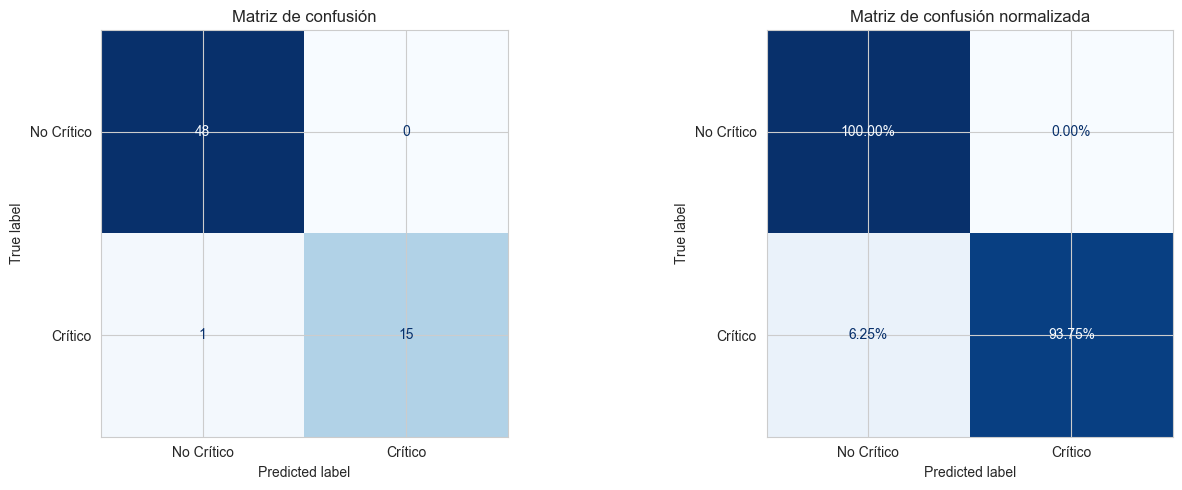

Verdaderos negativos: 48
Falsos positivos: 0
Falsos negativos (críticos no detectados): 1
Verdaderos positivos (críticos detectados): 15


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Crítico", "Crítico"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Matriz de confusión")

cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
ConfusionMatrixDisplay(cm_norm, display_labels=["No Crítico", "Crítico"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2%"
)
axes[1].set_title("Matriz de confusión normalizada")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos negativos: {tn}")
print(f"Falsos positivos: {fp}")
print(f"Falsos negativos (críticos no detectados): {fn}")
print(f"Verdaderos positivos (críticos detectados): {tp}")


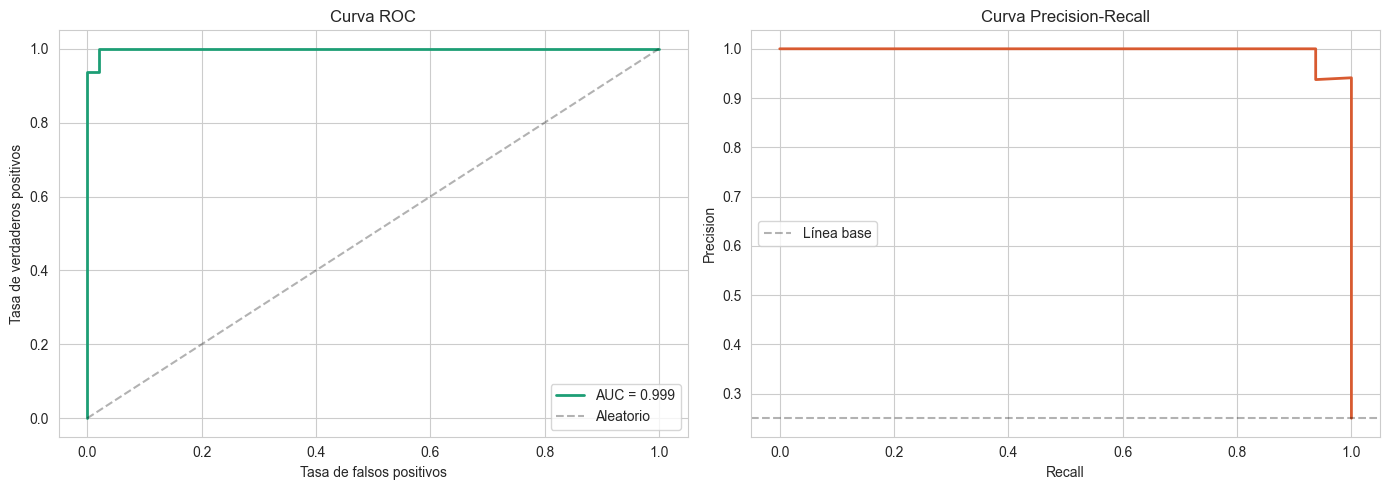

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color="#1D9E75", linewidth=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Aleatorio")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC")
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision, color="#D85A30", linewidth=2)
axes[1].axhline(y=y_test.mean(), color="k", linestyle="--", alpha=0.3, label="Línea base")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()


## Importancia de features

Variables con mayor peso en la predicción de circuitos críticos.


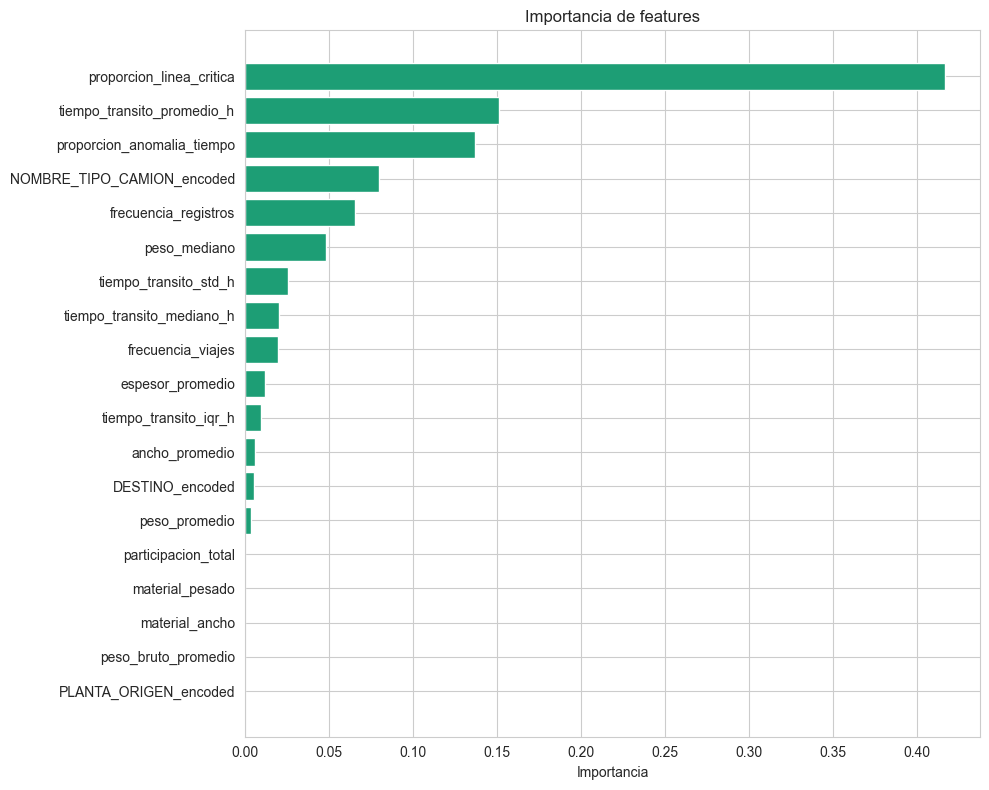

Top 5 features:
  0.4165 - proporcion_linea_critica
  0.1510 - tiempo_transito_promedio_h
  0.1368 - proporcion_anomalia_tiempo
  0.0799 - NOMBRE_TIPO_CAMION_encoded
  0.0657 - frecuencia_registros


In [13]:
df_imp = pd.DataFrame({
    "feature": all_features,
    "importancia": mejor_modelo.feature_importances_
}).sort_values("importancia", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_imp.feature, df_imp.importancia, color="#1D9E75")
ax.set_xlabel("Importancia")
ax.set_title("Importancia de features")
plt.tight_layout()
plt.show()

print("Top 5 features:")
for _, row in df_imp.tail(5).iloc[::-1].iterrows():
    print(f"  {row.importancia:.4f} - {row.feature}")


## Análisis de la optimización

Revisamos la convergencia de Optuna y la importancia de cada hiperparámetro.


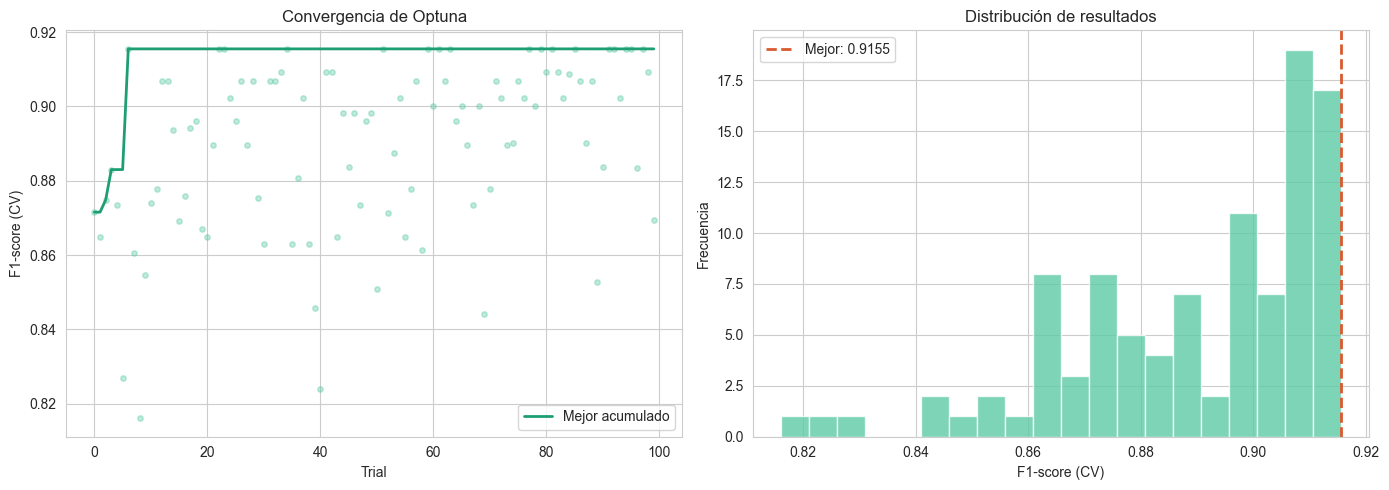

Importancia de los hiperparámetros:
  0.3162 - colsample_bytree
  0.3111 - reg_alpha
  0.1764 - scale_pos_weight
  0.0687 - n_estimators
  0.0519 - max_depth
  0.0396 - subsample
  0.0320 - learning_rate
  0.0040 - reg_lambda


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valores = [t.value for t in study.trials]
axes[0].scatter(range(len(valores)), valores, alpha=0.4, s=15, color="#5DCAA5")
axes[0].plot(pd.Series(valores).cummax(), color="#1D9E75", linewidth=2, label="Mejor acumulado")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("F1-score (CV)")
axes[0].set_title("Convergencia de Optuna")
axes[0].legend()

axes[1].hist(valores, bins=20, color="#5DCAA5", edgecolor="white", alpha=0.8)
axes[1].axvline(x=study.best_value, color="#D85A30", linewidth=2, linestyle="--",
                label=f"Mejor: {study.best_value:.4f}")
axes[1].set_xlabel("F1-score (CV)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de resultados")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Importancia de los hiperparámetros:")
for nombre, imp in optuna.importance.get_param_importances(study).items():
    print(f"  {imp:.4f} - {nombre}")


## Resumen

Métricas finales del modelo, para comparar contra el modelo con TDA.


In [15]:
print("Modelo Tradicional (Sin TDA) - XGBoost")
print(f"  Features:           {len(all_features)}")
print(f"  Circuitos:          {len(df)} (train {len(X_train)} / test {len(X_test)})")
print(f"  Umbral target (p75): {umbral_p75:.4f}")
print()
print(f"  Accuracy (test):    {acc:.4f}")
print(f"  F1-score (test):    {f1:.4f}")
print(f"  AUC-ROC (test):     {auc:.4f}")
print(f"  F1-score (CV):      {study.best_value:.4f}")
print()
print("  Top 3 features:")
for _, row in df_imp.tail(3).iloc[::-1].iterrows():
    print(f"    {row.importancia:.4f} - {row.feature}")


Modelo Tradicional (Sin TDA) - XGBoost
  Features:           19
  Circuitos:          318 (train 254 / test 64)
  Umbral target (p75): 0.2173

  Accuracy (test):    0.9844
  F1-score (test):    0.9677
  AUC-ROC (test):     0.9987
  F1-score (CV):      0.9155

  Top 3 features:
    0.4165 - proporcion_linea_critica
    0.1510 - tiempo_transito_promedio_h
    0.1368 - proporcion_anomalia_tiempo
